# Personality Prediction using Logistic Regression

## 1. Introduction

In this notebook, I have build a classification model using **Logistic Regression** to predict whether a person is an **Introvert (0)** or **Extrovert (1)** based on social behavior features.

Here I am using Logistic Regression is a simple yet powerful linear model suitable for **binary classification tasks**.

---

## 2. Dataset Source & Links

**Competition Name:** [Playground Series - Season 5, Episode 7](https://www.kaggle.com/competitions/playground-series-s5e7/overview)  
**Dataset Location:** `/kaggle/input/playground-series-s5e7`  
**Notebook by:** Krupa Dharamshi

---

## 3. Importing Required Libraries

We import Python libraries for:
- Data manipulation (`pandas`, `numpy`)
- Visualization (`matplotlib`, `seaborn`)
- Modeling (`sklearn`)


In [51]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd 
# data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e7/sample_submission.csv
/kaggle/input/playground-series-s5e7/train.csv
/kaggle/input/playground-series-s5e7/test.csv


## 4. Data Loading

In [52]:
train = pd.read_csv('/kaggle/input/playground-series-s5e7/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e7/test.csv')

## 5. Exploratory Data Analysis (EDA)

In [53]:
train.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [54]:
train.tail()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
18519,18519,3.0,No,7.0,3.0,No,9.0,7.0,Extrovert
18520,18520,1.0,NaN,6.0,7.0,No,6.0,5.0,Extrovert
18521,18521,7.0,Yes,1.0,1.0,Yes,1.0,NaN,Introvert
18522,18522,NaN,Yes,1.0,0.0,Yes,5.0,2.0,Introvert
18523,18523,1.0,No,8.0,6.0,No,4.0,7.0,Extrovert


In [55]:
train.shape

(18524, 9)

In [56]:
test.shape

(6175, 8)

In [57]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB


In [58]:
train.describe()

,id,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,18524.000000,17334.000000,17344.000000,17058.000000,17470.000000,17260.000000
mean,9261.500000,3.137764,5.265106,4.044319,7.996737,4.982097
std,5347.562529,3.003786,2.753359,2.062580,4.223484,2.879139
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4630.750000,1.000000,3.000000,3.000000,5.000000,3.000000
50%,9261.500000,2.000000,5.000000,4.000000,8.000000,5.000000
75%,13892.250000,4.000000,8.000000,6.000000,12.000000,7.000000
max,18523.000000,11.000000,10.000000,7.000000,15.000000,10.000000


In [59]:
train.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

In [60]:
test.isnull().sum()

id                             0
Time_spent_Alone             425
Stage_fear                   598
Social_event_attendance      397
Going_outside                466
Drained_after_socializing    432
Friends_circle_size          350
Post_frequency               408
dtype: int64

In [61]:
train['Personality'].value_counts()

Personality
Extrovert    13699
Introvert     4825
Name: count, dtype: int64

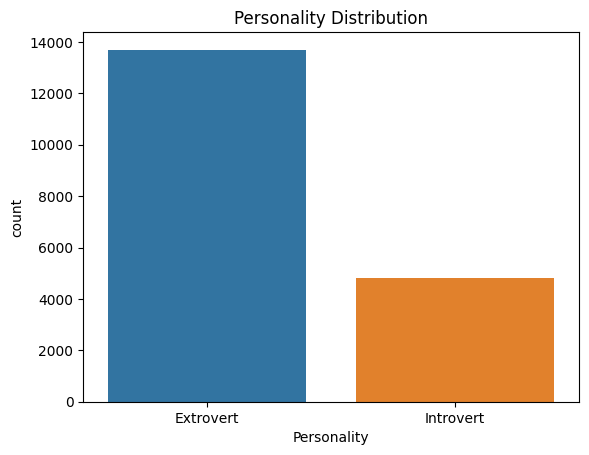

In [62]:
sns.countplot(data=train, x='Personality')
plt.title('Personality Distribution')
plt.show()

## 6. Handling Missing Values

In [63]:
num_cols = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 
            'Friends_circle_size', 'Post_frequency']

In [64]:
for col in num_cols:
    median = train[col].median()
    train[col] = train[col].fillna(median)
    test[col] = test[col].fillna(median)

In [65]:
cat_cols = ['Stage_fear', 'Drained_after_socializing']

In [66]:
for col in cat_cols:
    mode = train[col].mode()[0]
    train[col] = train[col].fillna(mode)
    test[col] = test[col].fillna(mode)

In [67]:
print(train.isnull().sum())
print(test.isnull().sum())

id                           0
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64
id                           0
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
dtype: int64


## 7. Encoding Categorical Columns

In [68]:
# Encode binary Yes/No columns
binary_map = {'Yes': 1, 'No': 0}
train['Stage_fear'] = train['Stage_fear'].map(binary_map)
train['Drained_after_socializing'] = train['Drained_after_socializing'].map(binary_map)
test['Stage_fear'] = test['Stage_fear'].map(binary_map)
test['Drained_after_socializing'] = test['Drained_after_socializing'].map(binary_map)

# Encode target column
target_map = {'Introvert': 0, 'Extrovert': 1}
train['Personality'] = train['Personality'].map(target_map)

In [69]:
train[['Stage_fear', 'Drained_after_socializing', 'Personality']].head()

,Stage_fear,Drained_after_socializing,Personality
0,0,0,1
1,0,0,1
2,1,0,0
3,0,0,1
4,0,0,1


## 8. Logistic Regression

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [71]:
features = ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 
            'Going_outside', 'Drained_after_socializing', 
            'Friends_circle_size', 'Post_frequency']

In [72]:
X = train[features]
y = train['Personality']

In [73]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [74]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [75]:
y_pred = model.predict(X_val)

In [76]:
print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))

Accuracy: 0.9651821862348178

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       965
           1       0.97      0.98      0.98      2740

    accuracy                           0.97      3705
   macro avg       0.96      0.95      0.95      3705
weighted avg       0.97      0.97      0.97      3705


Confusion Matrix:
 [[ 891   74]
 [  55 2685]]


In [77]:
test_preds = model.predict(test[features])

## 9. Submission

In [78]:
submission = pd.DataFrame({
    'id': test['id'],
    'Personality': test_preds
})

In [79]:
submission['Personality'] = submission['Personality'].map({0: 'Introvert', 1: 'Extrovert'})

In [80]:
submission.to_csv('submission.csv', index=False)